# Ensembling for Dataset A

In [1]:
import pandas as pd
import numpy as np
import datetime
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tcn import TCN
import time

In [ ]:
# Load and preprocess data

df = pd.read_csv("D:/SELC_AD/Code/paper_code/data/Dataset_D.csv", index_col='DateTime', parse_dates=True)


In [3]:
# Clean column names
df.columns = df.columns.str.strip() 
df.rename(columns={'KWH/hh (per half hour)': 'kwh'}, inplace=True)
df['kwh'] = df['kwh'].astype(str).str.strip()
df['kwh'] = pd.to_numeric(df['kwh'], errors='coerce')

In [ ]:
df = df.ffill()
data = df["kwh"].to_numpy().reshape((len(df["kwh"]), 1))

In [ ]:
# Z score normalization

mean_data = np.mean(data)
std_data = np.std(data)

if std_data == 0:
    data_normalized = data - mean_data
else:
    data_normalized = (data - mean_data) / std_data

print(mean_data)
print(std_data)

In [6]:
def truncate(x, feature_cols=range(1), target_cols=range(1), label_col=1, train_len=7, test_len=20):
    in_, out_= [], []
    for i in range(len(x)-train_len-test_len+1):
        in_.append(x[i:(i+train_len), feature_cols].tolist())
        out_.append(x[(i+train_len):(i+train_len+test_len), target_cols].tolist())
    return np.array(in_), np.array(out_)


X_in, X_out = truncate(data_normalized, feature_cols=range(1), target_cols=range(1), label_col=1, train_len=6, test_len=1)

In [ ]:
import math

# Total number of samples
n = X_in.shape[0]

# Calculate sizes
train_end = math.floor(n * 0.8)
val_end = math.floor(n * 0.9)

# 80% train
train_x = X_in[:train_end]
train_y = X_out[:train_end]

# 10% validation
val_x = X_in[train_end:val_end]
val_y = X_out[train_end:val_end]

# 10% test
test_x = X_in[val_end:]
test_y = X_out[val_end:]

train_y = np.repeat(train_y, 2, axis=1)
val_y = np.repeat(val_y, 2, axis=1)
test_y = np.repeat(test_y, 2, axis=1)

print(train_x.shape, train_y.shape)
print(val_x.shape, val_y.shape)
print(test_x.shape, test_y.shape)


In [8]:
r = 0.5
q = 0.95
delta = 0.018
l = 2

def confidance_loss(y_true, y_pred):
      y_true = y_true[:, 0]
      f1 = y_pred[:, 0]
      f2 = y_pred[:, 1]

      c1 = (1 - q) * (y_true - f2)
      c2 = (1 - q) * (f1 - y_true)
      c3 = q * (f2 - y_true)
      c4 = q * (y_true - f1)

      loss = tf.where(tf.math.logical_and(y_true <= f1, y_true >= f2),
                      tf.where(y_true > r * (f1 + f2), c1, c2),
                      tf.where(f2 > y_true, c3, c4)) + (delta * tf.math.abs(f1 - f2))

      return loss

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tcn import TCN

def build_tcn_model(input_shape, num_outputs=2, num_filters=64, kernel_size=3, nb_stacks=1, dilations=(1, 2, 4, 8), dropout_rate=0.3):

    inputs = Input(shape=input_shape)
    x = TCN(nb_filters=num_filters,
            kernel_size=kernel_size,
            nb_stacks=nb_stacks,
            dilations=dilations,
            dropout_rate=dropout_rate,
            return_sequences=False)(inputs)

    outputs = Dense(num_outputs)(x)

    model = Model(inputs, outputs)
    return model

In [23]:
# ------------------- ENSEMBLE TRAINING -------------------
results = []
batch_size = 32

for run in range(1, 6):
    print(f"\n===== RUN {run} =====")
    # tf.keras.utils.set_random_seed(run)  # different seed for each run

    model = build_tcn_model(input_shape=(train_x.shape[1], train_x.shape[2]))
    model.compile(loss=confidance_loss, optimizer=Adam(learning_rate=0.001))

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, mode='min')
    start_time = datetime.datetime.now()

    model.fit(train_x, train_y, validation_data=(val_x, val_y),
              epochs=100, batch_size=batch_size, verbose=1, callbacks=[early_stopping])

    end_time = datetime.datetime.now()
    print('Training time (sec):', round((end_time - start_time).total_seconds(), 1))

    # ----- Validation -----
    val_pred = model.predict(val_x, verbose=0)
    val_y_true = np.squeeze(val_y[:, 0]) * std_data + mean_data
    val_u = val_pred[:, 0] * std_data + mean_data
    val_l = val_pred[:, 1] * std_data + mean_data


    # ----- Test -----
    test_pred = model.predict(test_x, verbose=0)
    test_y_true = np.squeeze(test_y[:, 0]) * std_data + mean_data
    test_u = test_pred[:, 0] * std_data + mean_data
    test_l = test_pred[:, 1] * std_data + mean_data
    np.save(f"TCN_TUBE_UK_test_upper_run{run}_dtD.npy", test_u)
    np.save(f"TCN_TUBE_UK_test_lower_run{run}_dtD.npy", test_l)

    # Metrics
    val_picp = np.mean((val_u > val_y_true) * (val_l < val_y_true))
    val_mpiw = np.mean(val_u - val_l)
    test_picp = np.mean((test_u > test_y_true) * (test_l < test_y_true))
    test_mpiw = np.mean(test_u - test_l)

    results.append({
        "Run": run,
        "Val_PICP": val_picp,
        "Val_MPIW": val_mpiw,
        "Test_PICP": test_picp,
        "Test_MPIW": test_mpiw
    })



===== RUN 1 =====
Epoch 1/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4235 - val_loss: 0.0948
Epoch 2/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1156 - val_loss: 0.0941
Epoch 3/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1139 - val_loss: 0.0967
Epoch 4/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1133 - val_loss: 0.0934
Epoch 5/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1135 - val_loss: 0.0924
Epoch 6/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1091 - val_loss: 0.0940
Epoch 7/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1084 - val_loss: 0.0941
Epoch 8/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1078 - val_loss: 0.0925
Epoch 9/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1059 - val_loss: 0.0968
Epoch 10/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1109 - val_loss: 0.0945
Epoch 11/100
978/978 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1064 - val_loss: 0.0942
Epoch 12/100
978/978 

In [ ]:
# ================== Save results ==================
results_df = pd.DataFrame(results)
results_df.to_excel("ensemble_results_dtD.xlsx", index=False)
print("\nResults saved to Excel.")

In [25]:

# ================== Save test data ==================
np.save("test_X_dtD.npy", test_x)
np.save("test_y_dtD.npy", test_y)

## Computing final PICP & MPIW (AFTER ENSEMBLING)

In [26]:
# Path where bounds are stored
base_path = ""
runs = 5

In [27]:
# Load test_y

import os

test_y = np.load(os.path.join(base_path, "test_y_dtD.npy"))

# Storage for all runs
all_upper = []
all_lower = []

In [28]:
# Load bounds from each run
for run in range(1, runs+1):
    folder_path = os.path.join(base_path, f"it{run}")
    lower_bounds = np.load(os.path.join(base_path, f"TCN_TUBE_UK_test_lower_run{run}_dtD.npy"))
    upper_bounds = np.load(os.path.join(base_path, f"TCN_TUBE_UK_test_upper_run{run}_dtD.npy"))
    
    all_lower.append(lower_bounds)
    all_upper.append(upper_bounds)

In [29]:
# Convert to arrays: shape = (runs, num_samples)
all_lower = np.array(all_lower)
all_upper = np.array(all_upper)

# Mean across runs (axis=0 → average over runs)
mean_lower = np.mean(all_lower, axis=0)
mean_upper = np.mean(all_upper, axis=0)

In [30]:
# Std. deviation (sigma) across runs
sigma_lower = np.std(all_lower, axis=0, ddof=1)  # ddof=1 for sample std
sigma_upper = np.std(all_upper, axis=0, ddof=1)

In [ ]:
print(np.mean(sigma_lower))
print(np.mean(sigma_upper))

In [32]:
# Calculate new bounds using formula
factor = 1.96 * (1 / np.sqrt(runs))
new_upper = mean_upper + factor * sigma_upper
new_lower = mean_lower - factor * sigma_lower

In [ ]:
test_y_true = np.squeeze(test_y[:, 0]) * std_data + mean_data

PICP = np.mean((new_upper > test_y_true) * (new_lower < test_y_true))
MPIW = np.mean(new_upper - new_lower)
print(PICP)
print(MPIW)

# Plots

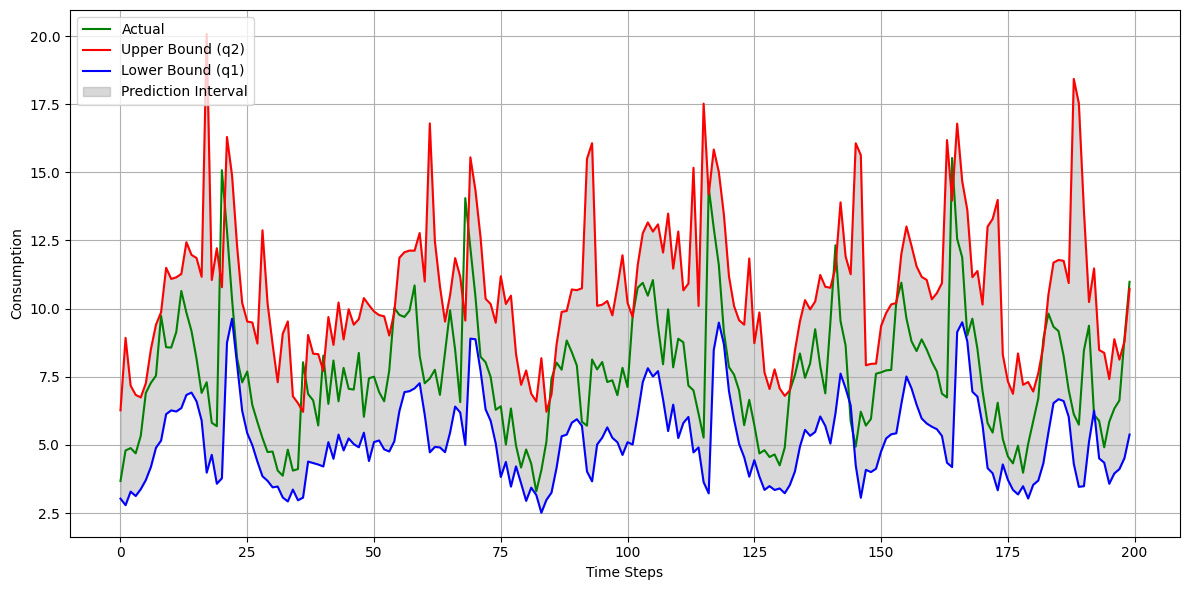

In [35]:
import matplotlib.pyplot as plt
# Choose a slice — e.g., first 200 points
start = 0
end = 200  # Or any other small window

subset_range = range(start, end)

plt.figure(figsize=(12, 6))
plt.plot(subset_range, test_y_true[start:end], label='Actual', color='green')
plt.plot(subset_range, new_upper[start:end], label='Upper Bound (q2)', color='red')
plt.plot(subset_range, new_lower[start:end], label='Lower Bound (q1)', color='blue')
plt.fill_between(subset_range, new_lower[start:end], new_upper[start:end], color='gray', alpha=0.3, label='Prediction Interval')
plt.xlabel('Time Steps')
plt.ylabel('Consumption')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# End